Introduction -
The analysis uses the 2013 Living Costs and Food Survey (LCF) teaching dataset to examine whether household expenditure is associated with occupational class, tenure type, number of adults, and number of children. This question is relevant because expenditure is closely linked to living standards, household needs, and socio-economic inequality. The LCF is an important UK survey used to inform national statistics on prices, household expenditure, taxes, benefits, and living conditions.

Research question -
Is there a relationship between occupational class, tenure type, number of adults, number of children and household expenditure?

# Data and Variables

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# 1. Load data

df_raw = pd.read_stata("LCF.dta")
df_raw.info()
df_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5144 entries, 0 to 5143
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   casenew      5144 non-null   int16   
 1   weighta      5144 non-null   float64 
 2   P550tpr      5144 non-null   float64 
 3   P344pr       5144 non-null   float64 
 4   P425r        5144 non-null   category
 5   A172         5144 non-null   category
 6   A093r        5144 non-null   category
 7   A094r        5144 non-null   category
 8   A121r        5144 non-null   category
 9   SexHRP       5144 non-null   category
 10  A049r        5144 non-null   category
 11  G018r        5144 non-null   category
 12  G019r        5144 non-null   category
 13  Gorx         5144 non-null   category
 14  weightar     5144 non-null   float64 
 15  maininc      5144 non-null   category
 16  income       5144 non-null   float32 
 17  expenditure  5144 non-null   float32 
 18  hhsize       5144 non-null  

,casenew,weighta,P550tpr,P344pr,P425r,A172,A093r,A094r,A121r,SexHRP,A049r,G018r,G019r,Gorx,weightar,maininc,income,expenditure,hhsize
0,14999,2.834724,380.695762,465.36,Earned income,Yes,Economically inactive,Routine and manual occupations,Public rented,Female,4 person,2 adults,Two or more children,East Midlands,0.543248,earnings,465.359985,380.695770,4
1,14993,10.077947,546.413403,855.26,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Female,2 person,2 adults,No children,London,1.931344,earnings,855.260010,546.413391,2
2,14993,4.088676,242.189023,160.96,Earned income,Yes,Full-time working,Intermediate occupations,Owned,Female,1 person,1 adult,No children,South East,0.783557,earnings,160.960007,242.189026,1
3,14984,4.571760,421.382353,656.22,Earned income,Yes,Full-time working,Routine and manual occupations,Owned,Male,2 person,2 adults,No children,Eastern,0.876135,earnings,656.219971,421.382355,2
4,14981,7.349617,370.405577,398.80,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Male,1 person,1 adult,No children,South East,1.408485,earnings,398.799988,370.405579,1


Variables of interest -
The dependent variable is expenditure, a continuous quantitative variable. The explanatory variables are occupational_class, tenure_type, number_of_adults, and number_of_children, all of which are categorical variables.


In [ ]:
# 2. Rename variables

df_raw = df_raw.rename(columns={
    "A094r": "occupational_class",
    "A121r": "tenure_type",
    "G018r": "number_of_adults",
    "G019r": "number_of_children"
})

In [ ]:
# 3. Keep only variables of interest

df = df_raw[[
    "expenditure",
    "occupational_class",
    "tenure_type",
    "number_of_adults",
    "number_of_children"
]].copy()

# Data preparation & statistics

In [ ]:
# 4. Check missing values and structure

print("Missing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)
print("\nPreview:")
print(df.head())

Missing values:
expenditure           0
occupational_class    0
tenure_type           0
number_of_adults      0
number_of_children    0
dtype: int64

Data types:
expenditure            float32
occupational_class    category
tenure_type           category
number_of_adults      category
number_of_children    category
dtype: object

Preview:
   expenditure                                 occupational_class  \
0   380.695770                     Routine and manual occupations   
1   546.413391  Never worked and long term unemployed, student...   
2   242.189026                           Intermediate occupations   
3   421.382355                     Routine and manual occupations   
4   370.405579  Never worked and long term unemployed, student...   

     tenure_type number_of_adults    number_of_children  
0  Public rented         2 adults  Two or more children  
1          Owned         2 adults           No children  
2          Owned          1 adult           No children  
3          O

4. Check missing values and structure -
An initial data check showed no missing values across all variables, indicating a complete dataset. Household expenditure is a continuous variable, while occupational class, tenure type, and household composition variables are categorical. The categories are clearly labelled, making them suitable for inclusion as factor variables in the analysis. Overall, the dataset is well-structured and requires no further cleaning before modelling.

In [ ]:
# 5. Descriptive statistics

print("\nDescriptive statistics for expenditure:")
print(df["expenditure"].describe())

print("\nCategory counts:")
for col in ["occupational_class", "tenure_type", "number_of_adults", "number_of_children"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Descriptive statistics for expenditure:
count    5144.000000
mean      479.758423
std       292.365234
min        30.525000
25%       254.127823
50%       419.903442
75%       644.974411
max      1175.000000
Name: expenditure, dtype: float64

Category counts:

occupational_class
occupational_class
Not classified for other reasons                                             1619
Higher managerial, administrative and professional occupations               1589
Routine and manual occupations                                               1045
Intermediate occupations                                                      691
Never worked and long term unemployed, students and occupation not stated     200
Name: count, dtype: int64

tenure_type
tenure_type
Owned             3466
Public rented      880
Private rented     798
Name: count, dtype: int64

number_of_adults
number_of_adults
2 adults             2826
1 adult              1729
3 adults              422
4 and more adults     167
Name:


5. Descriptive statistics -
Descriptive statistics for household expenditure indicate a mean value of approximately £479.76, with a median of £419.90. The difference between the mean and the median suggests a positively skewed distribution, which is consistent with the presence of higher expenditure values in the upper tail. The standard deviation is relatively large (£292.37), indicating substantial variability in household spending across the sample. Expenditure ranges from a minimum of £30.53 to a maximum of £1,175.00, further highlighting the wide dispersion in consumption levels.

- Occupational class
In terms of occupational class, the largest group in the sample is ‘Not classified for other reasons’ (1,619 households), followed closely by ‘Higher managerial, administrative and professional occupations’ (1,589 households). ‘Routine and manual occupations’ account for 1,045 households, while ‘Intermediate occupations’ represent a smaller proportion (691 households). The smallest group consists of households where individuals have never worked, are long-term unemployed, or where occupation is not stated (200 households).

- Tenure type
Regarding housing tenure, the majority of households are owner-occupied (3,466), followed by public rented accommodation (880) and private rented accommodation (798). This distribution suggests that home ownership is the dominant tenure type within the sample.

- Household composition (adults)
The distribution of the number of adults shows that most households consist of two adults (2,826), followed by single-adult households (1,729). Households with three adults (422) and those with four or more adults (167) are considerably less common.

- Household composition (children)
With respect to the number of children, the majority of households have no children (3,605). Households with two or more children account for 885 observations, while those with one child represent 654 households. This indicates that childless households are the most prevalent in the dataset.


Overall, the descriptive statistics and category distributions reveal substantial variation in household expenditure and highlight the diversity of socio-economic and demographic characteristics within the sample, providing a solid basis for further analysis.


# Methodology & Hypotheses

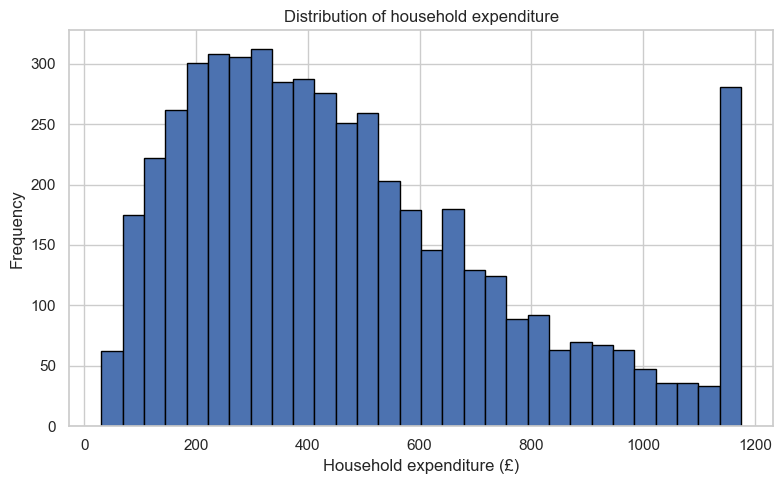

   expenditure  log_expenditure
0   380.695770         5.942000
1   546.413391         6.303376
2   242.189026         5.489718
3   421.382355         6.043540
4   370.405579         5.914598


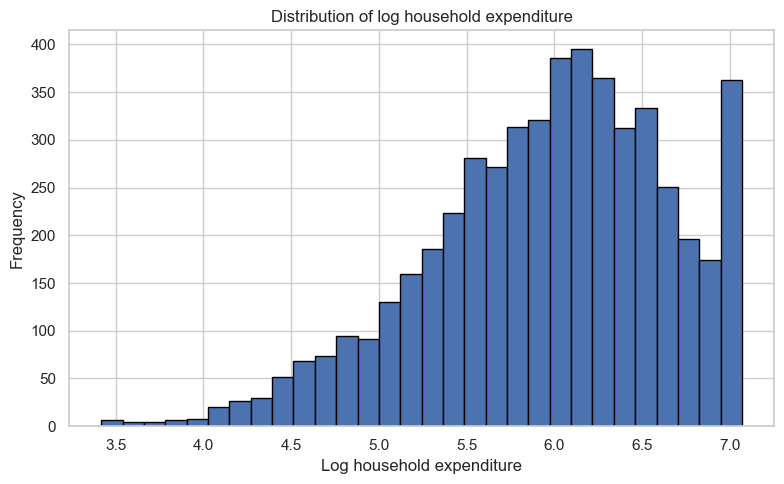

In [ ]:
# 6. Plot raw expenditure distribution

plt.figure(figsize=(8, 5))
plt.hist(df["expenditure"], bins=30, edgecolor="black")
plt.xlabel("Household expenditure (£)")
plt.ylabel("Frequency")
plt.title("Distribution of household expenditure")
plt.tight_layout()
plt.show()

# Creating a new logarithmic expenditure column
df["log_expenditure"] = np.log(df["expenditure"])
print(df[["expenditure", "log_expenditure"]].head())

# Plot log expenditure distribution
plt.figure(figsize=(8, 5))
plt.hist(df["log_expenditure"], bins=30, edgecolor="black")
plt.xlabel("Log household expenditure")
plt.ylabel("Frequency")
plt.title("Distribution of log household expenditure")
plt.tight_layout()
plt.show()



6. Plot expenditure distribution -
The distribution of household expenditure is clearly positively skewed, with a long right tail reflecting a small number of high-spending households. Such asymmetry is common in expenditure data and raises concerns regarding the normality assumption required for linear regression. To address this issue, a logarithmic transformation was applied, which is expected to produce a more symmetric distribution and improve model performance.
Following the logarithmic transformation of household expenditure, shows a more balanced distribution, that becomes noticeably more symmetric and closer to a normal shape, with observations more evenly spread around the centre. This suggests that the transformation has improved the suitability of the variable for linear regression analysis.

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="expenditure", palette=palette)


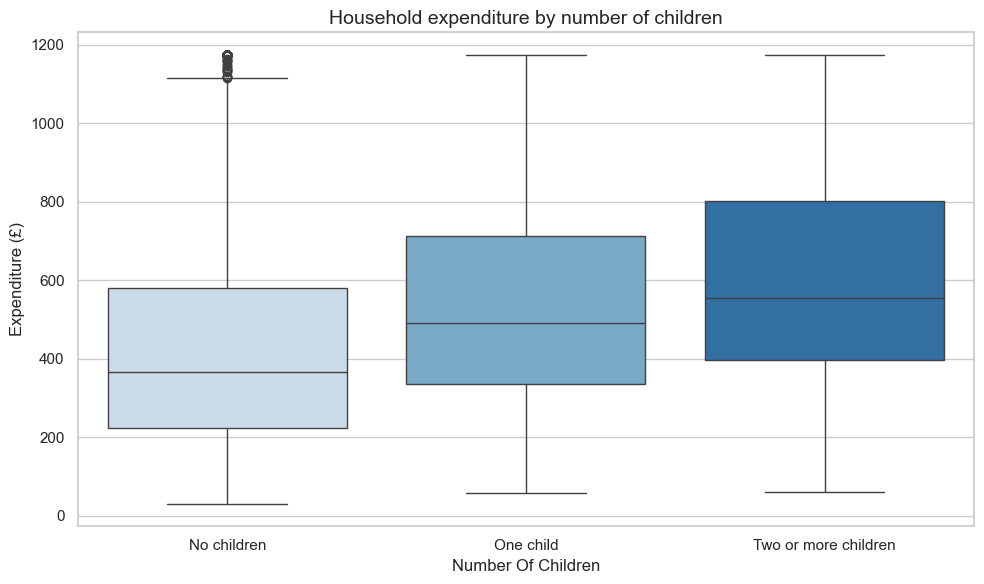

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="expenditure", palette=palette)


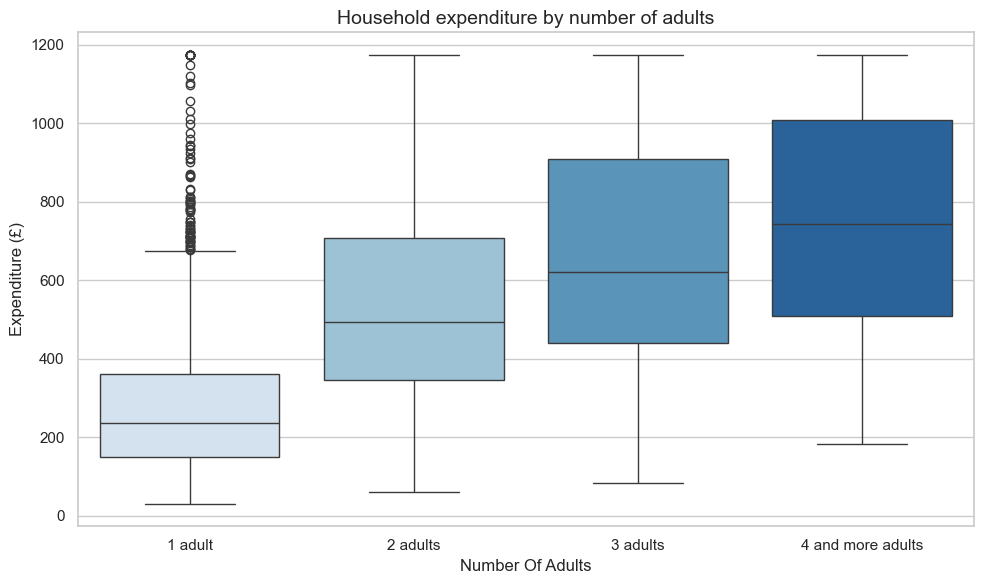

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="expenditure", palette=palette)


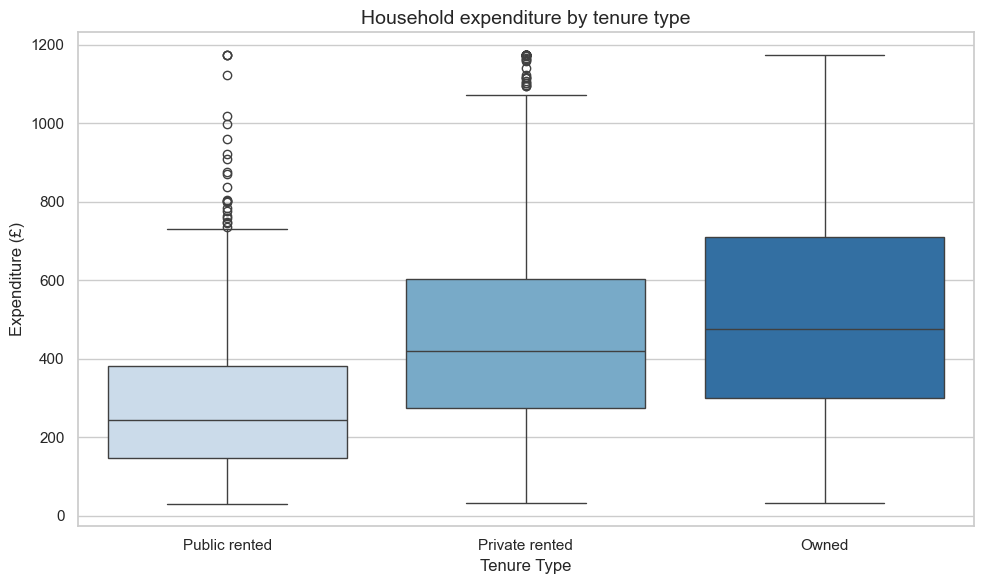

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="log_expenditure", palette=palette)


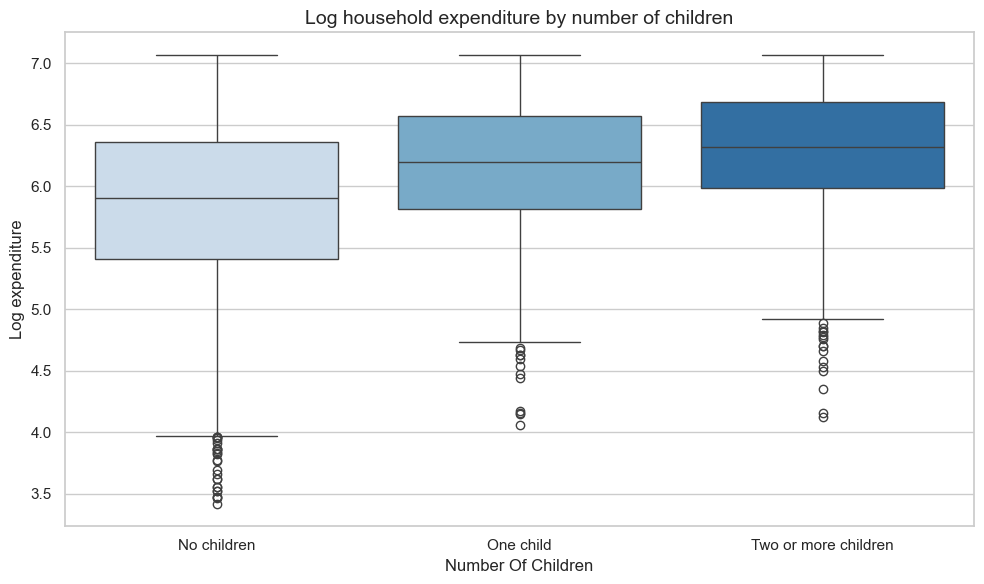

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="log_expenditure", palette=palette)


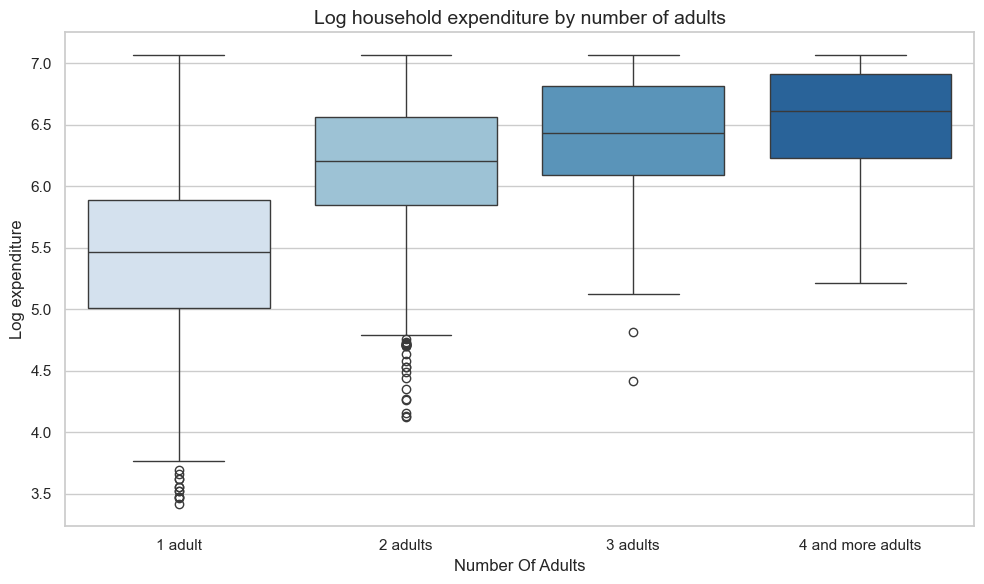

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="log_expenditure", palette=palette)


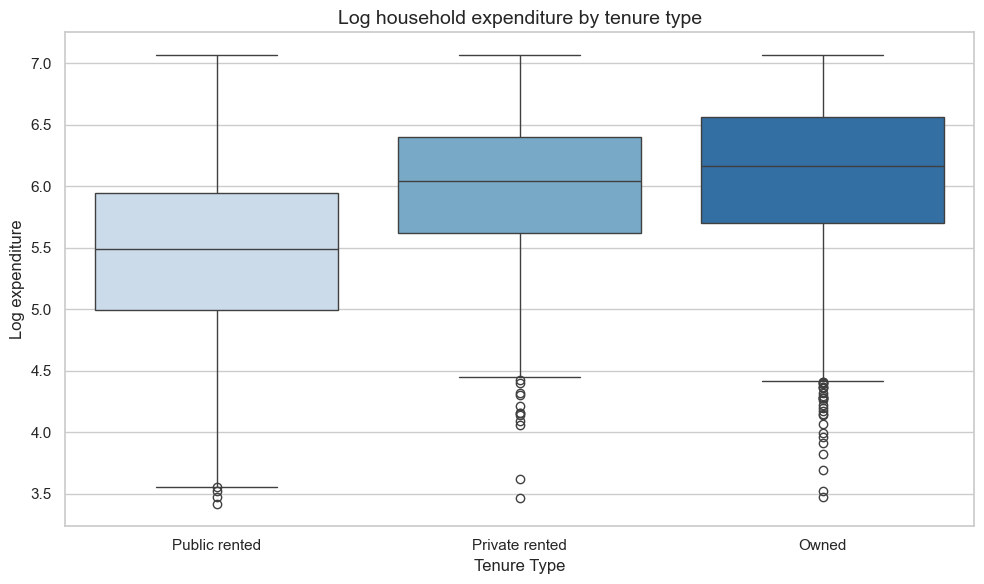

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


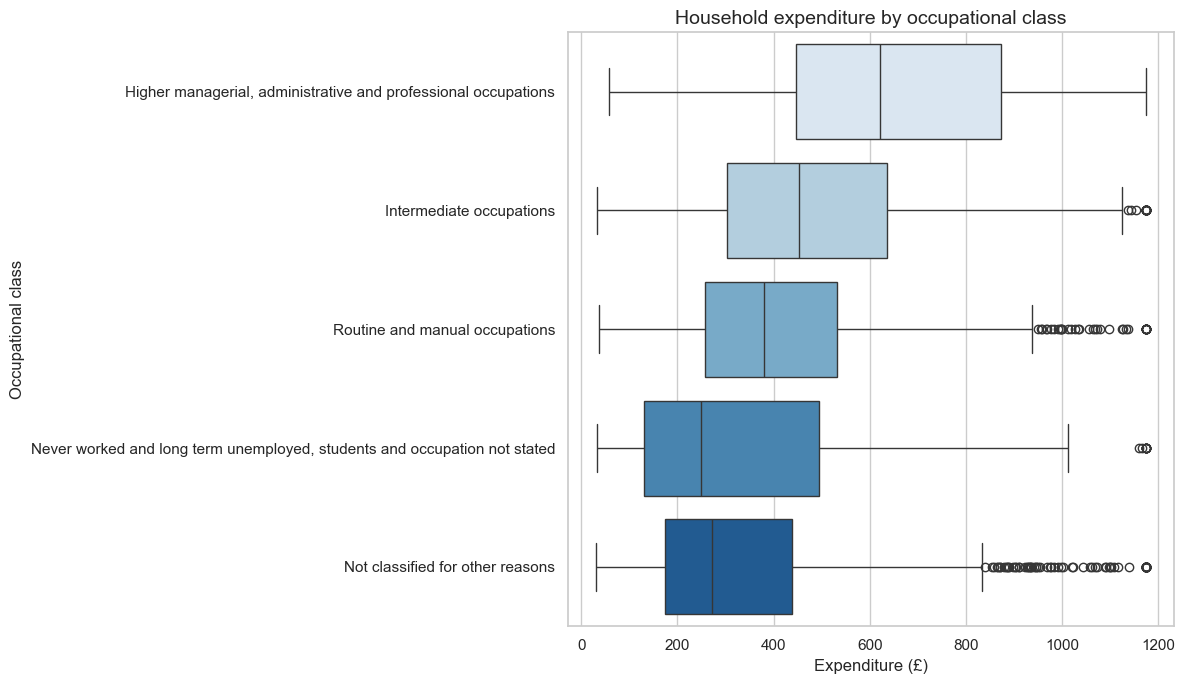

C:\Users\selma\AppData\Local\Temp\ipykernel_12924\1134812366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


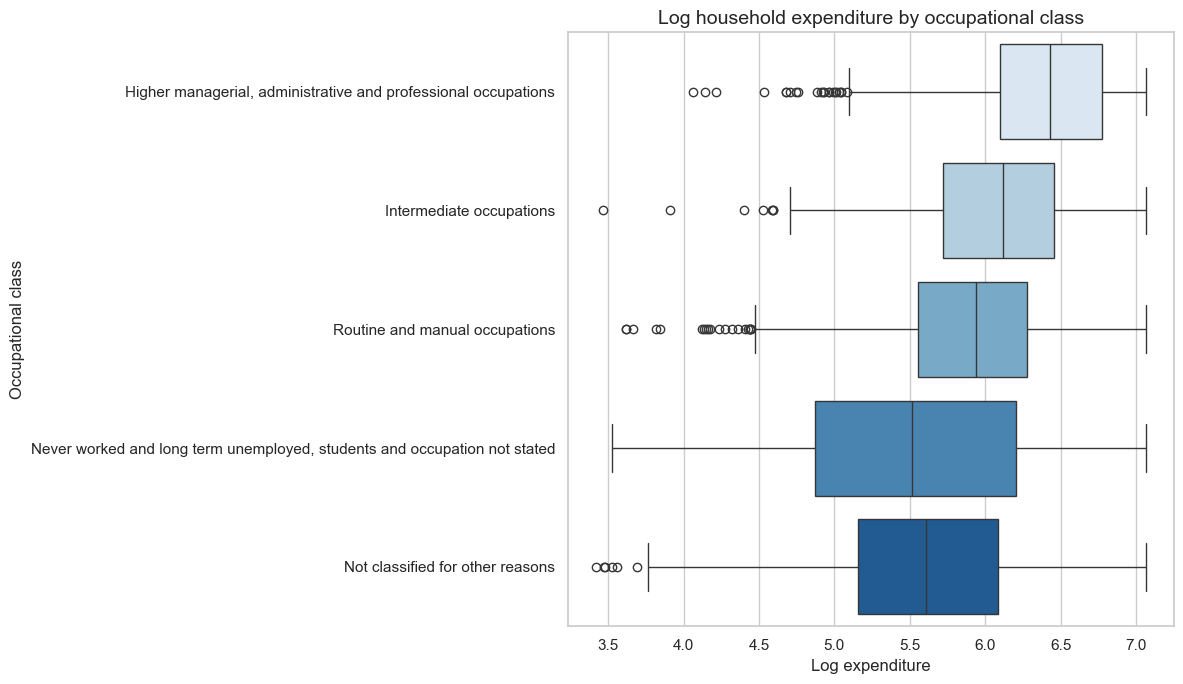

In [ ]:
# 7. Boxplots by categorical predictors

sns.set(style="whitegrid")
palette = "Blues"

for col in ["number_of_children", "number_of_adults", "tenure_type"]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col, y="expenditure", palette=palette)
    plt.title(f"Household expenditure by {col.replace('_', ' ')}", fontsize=14)
    plt.xlabel(col.replace("_", " ").title(), fontsize=12)
    plt.ylabel("Expenditure (£)", fontsize=12)
    plt.tight_layout()
    plt.show()

for col in ["number_of_children", "number_of_adults", "tenure_type"]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col, y="log_expenditure", palette=palette)
    plt.title(f"Log household expenditure by {col.replace('_', ' ')}", fontsize=14)
    plt.xlabel(col.replace("_", " ").title(), fontsize=12)
    plt.ylabel("Log expenditure", fontsize=12)
    plt.tight_layout()
    plt.show()

occupation_order = [
    "Higher managerial, administrative and professional occupations",
    "Intermediate occupations",
    "Routine and manual occupations",
    "Never worked and long term unemployed, students and occupation not stated",
    "Not classified for other reasons"
]



plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df,
    x="expenditure",
    y="occupational_class",
    order=occupation_order,
    palette="Blues"
)
plt.title("Household expenditure by occupational class", fontsize=14)
plt.xlabel("Expenditure (£)", fontsize=12)
plt.ylabel("Occupational class", fontsize=12)
plt.tight_layout()
plt.show()



plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df,
    x="log_expenditure",
    y="occupational_class",
    order=occupation_order,
    palette="Blues"
)
plt.title("Log household expenditure by occupational class", fontsize=14)
plt.xlabel("Log expenditure", fontsize=12)
plt.ylabel("Occupational class", fontsize=12)
plt.tight_layout()
plt.show()

7. Boxplots by categorical predictors -
Boxplots were produced for both the raw household expenditure and its logarithmic transformation in order to assess the distribution and improve interpretability. The raw expenditure plots highlight overall variability and reveal clear differences across groups, but they are strongly affected by positive skewness and the presence of extreme values, which makes comparisons less clear.
In contrast, the log-transformed plots display a more symmetric and balanced distribution, reducing the influence of outliers and allowing for clearer comparisons of median expenditure across categories. Importantly, the underlying relationships remain consistent in both representations, with higher household composition and socio-economic status associated with higher expenditure.
For this reason, both visualisations are retained: the raw plots provide useful descriptive context, while the log-transformed plots offer a more reliable and interpretable basis for analysis and modelling.

8. Modelling strategy - OLS regression was used since the dependent variable is continuous, and the model allows the inclusion of categorical explanatory variables.

In [ ]:
# 8. Fit OLS models

model_raw = ols("""
expenditure ~ C(occupational_class)
            + C(tenure_type)
            + C(number_of_adults)
            + C(number_of_children)
""", data=df).fit()
print("\nRAW OLS summary:")
print(model_raw.summary())



model_log = ols("""
log_expenditure ~ C(occupational_class)
                + C(tenure_type)
                + C(number_of_adults)
                + C(number_of_children)
""", data=df).fit()
print("\nLOG OLS summary:")
print(model_log.summary())


RAW OLS summary:
                            OLS Regression Results                            
Dep. Variable:            expenditure   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     327.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:41:10   Log-Likelihood:                -35139.
No. Observations:                5144   AIC:                         7.030e+04
Df Residuals:                    5132   BIC:                         7.038e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

8. Fit OLS models -
The model provides an initial benchmark for understanding the direction, magnitude, and statistical significance of the relationships between expenditure and household characteristics.
The results indicate significant effects of occupational class, tenure type, and household composition on expenditure. However, diagnostic tests reveal deviations from OLS assumptions, particularly non-normality and potential heteroscedasticity.
Two models were estimated: one using raw expenditure and another using log expenditure. The raw model was useful as a baseline and for descriptive interpretation in pounds, while the log model was preferred for inference because it reduced skewness and improved the distributional properties of the residuals.

In [ ]:
# As the survey includes households from both Great Britain and Northern Ireland.
# Northern Ireland CHECK was conducted by estimating the model without the Northern Ireland observations to assess whether regional differences influenced the results.
#Northern Ireland CHECK: excluding Northern Ireland

#df_noni = df_raw[df_raw["Gorx"] != "Northern Ireland"].copy()
# Keep only variables of interest
#df_noni = df_noni[
#    ["expenditure", "occupational_class", "tenure_type",
#     "number_of_adults", "number_of_children"]
#].copy()


#  Northern Ireland CHECK Log
#df_noni = df_noni[df_noni["expenditure"] > 0].copy()
#df_noni["log_expenditure"] = np.log(df_noni["expenditure"])
# Model
#model_lognoni = ols("""
#log_expenditure ~ C(occupational_class)
#                + C(tenure_type)
#                + C(number_of_adults)
#                + C(number_of_children)
#""", data=df_noni).fit()


# Northern Ireland CHECK Analysis
#print("R-squared (full sample):", model_log.rsquared)
#print("R-squared (excluding NI):", model_lognoni.rsquared)
#print("Full sample R² =", round(model_log.rsquared, 4))
#print("Excluding NI R² =", round(model_lognoni.rsquared, 4))
#print(model_log.params)
#print(model_lognoni.params)


# Although Northern Ireland differs economically and institutionally from Great Britain.
# The Northern Ireland CHECK analysis shows that excluding its observations does not materially affect the results.
# This suggests that the determinants of household expenditure identified in this study reflect broader UK-wide patterns rather than region-specific effects.
# Therefore, the full sample was retained to maximise statistical power and representativeness.

9. ANOVA  -
ANOVA is particularly suitable given the use of categorical predictors, as it decomposes the total variation in household expenditure into components attributable to each factor, allowing a direct comparison of their relative importance.

In [ ]:
# 9. ANOVA

def compute_anova_with_eta(model, label):
    anova = sm.stats.anova_lm(model, typ=2)
    residual_ss = anova.loc["Residual", "sum_sq"]
    anova["partial_eta_sq"] = anova["sum_sq"] / (anova["sum_sq"] + residual_ss)
    print(f"\nANOVA table ({label}):")
    print(anova)
    return anova
anova_raw = compute_anova_with_eta(model_raw, "RAW")
anova_log = compute_anova_with_eta(model_log, "LOG")


ANOVA table (RAW):
                             sum_sq      df           F         PR(>F)  \
C(occupational_class)  3.793599e+07     4.0  188.425238  6.476706e-151   
C(tenure_type)         1.087202e+07     2.0  108.001036   1.137568e-46   
C(number_of_adults)    6.066308e+07     3.0  401.745309  2.077543e-234   
C(number_of_children)  4.586000e+06     2.0   45.556636   2.446718e-20   
Residual               2.583087e+08  5132.0         NaN            NaN   

                       partial_eta_sq  
C(occupational_class)        0.128056  
C(tenure_type)               0.040389  
C(number_of_adults)          0.190183  
C(number_of_children)        0.017444  
Residual                     0.500000  

ANOVA table (LOG):
                            sum_sq      df           F         PR(>F)  \
C(occupational_class)   196.770024     4.0  203.407519  3.552107e-162   
C(tenure_type)           89.114216     2.0  184.240477   5.338645e-78   
C(number_of_adults)     410.188357     3.0  565.366576  

9. ANOVA -
The ANOVA results showed that all explanatory variables were statistically significant in both models, indicating that each contributed meaningfully to explaining household expenditure. Across both specifications, the number of adults was the most important predictor, followed by occupational class, then tenure type, while the number of children had the smallest but still significant contribution.

10. Robust standard errors for inference -
Given these limitations, the baseline OLS results should be interpreted with caution. To address potential heteroscedasticity and ensure more reliable statistical inference, robust standard errors (HC3) are subsequently employed. HC3 was preferred due to its superior finite-sample properties and its ability to mitigate the influence of high-leverage observations. This is particularly relevant given the presence of outliers and the non-normal distribution of expenditure.

In [ ]:
# 10. Robust standard errors for inference

model_raw_hc3 = model_raw.get_robustcov_results(cov_type="HC3")
print("\nRAW OLS summary with HC3 robust standard errors:")
print(model_raw_hc3.summary())


model_log_hc3 = model_log.get_robustcov_results(cov_type="HC3")
print("\nLOG OLS summary with HC3 robust standard errors:")
print(model_log_hc3.summary())


RAW OLS summary with HC3 robust standard errors:
                            OLS Regression Results                            
Dep. Variable:            expenditure   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     392.2
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:41:10   Log-Likelihood:                -35139.
No. Observations:                5144   AIC:                         7.030e+04
Df Residuals:                    5132   BIC:                         7.038e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                                                                                         coef    std err          t      P>|t|      [0.025      

10. Robust standard errors for inference
Robust standard errors (HC3) were applied to both the raw and log-transformed models. While the logarithmic transformation reduces skewness and improves the distribution of the dependent variable, it does not necessarily eliminate heteroscedasticity. Therefore, robust standard errors were employed in both specifications to ensure valid statistical inference.
The correction is particularly important for the raw model, where the presence of outliers and strong dispersion suggests substantial heteroscedasticity. In the log-transformed model, although the distribution is more stable, the use of HC3 remains a precautionary measure to guarantee the reliability of standard errors and hypothesis tests.


In [ ]:
# Chi-square tests are used here as a complementary analysis.
# They assess whether the categorical explanatory variables
# are associated with one another.
# This does not directly answer the main research question,
# because expenditure is continuous, but it helps describe
# the socio-economic structure of the sample.
#
#def cramers_v(confusion_matrix):
#chi2 = chi2_contingency(confusion_matrix)[0]
#    n = confusion_matrix.sum().sum()
#    r, k = confusion_matrix.shape
#    return np.sqrt(chi2 / (n * (min(r, k) - 1)))
#
#pairs = [
#    ("number_of_adults", "tenure_type"),
#    ("number_of_adults", "occupational_class"),
#    ("number_of_children", "tenure_type"),
#    ("tenure_type", "occupational_class")
#]
#
#results = []
#
#for var1, var2 in pairs:
#    table = pd.crosstab(df[var1], df[var2])
#    chi2, p, dof, expected = chi2_contingency(table)
#    cv = cramers_v(table)
#
#    results.append({
#        "Variable 1": var1,
#        "Variable 2": var2,
#        "Chi-square": round(chi2, 3),
#        "df": dof,
#        "p-value": round(p, 5),
#        "Cramer's V": round(cv, 3)
#    })
#
#chi_results = pd.DataFrame(results)
#
#print("\nChi-square test results:")
#print(chi_results)
# The Chi-square tests complement the regression analysis by providing insight into the structure of relationships among explanatory variables.
# While the regression model focuses on the effect of these variables on household expenditure, the Chi-square results confirm that these factors are interconnected and reflect broader socio-economic patterns.
# The results suggest that the explanatory variables jointly reflect broader socio-economic dimensions, rather than acting as independent factors.
#
#
# Variance Inflation Factors (VIF) were computed to assess the presence of multicollinearity among the explanatory variables.
# This diagnostic is particularly relevant given that the model includes several categorical predictors that may be related to each other, as previously indicated by the Chi-square tests.
X = model_log.model.exog
vif_table = pd.DataFrame({
    "variable": model_log.model.exog_names,
    "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
print(vif_table)



                                             variable        VIF
0                                           Intercept  12.919175
1   C(occupational_class)[T.Intermediate occupations]   1.258415
2   C(occupational_class)[T.Routine and manual occ...   1.411351
3   C(occupational_class)[T.Never worked and long ...   1.168640
4   C(occupational_class)[T.Not classified for oth...   1.660119
5                    C(tenure_type)[T.Private rented]   1.684634
6                             C(tenure_type)[T.Owned]   1.827703
7                     C(number_of_adults)[T.2 adults]   1.327182
8                     C(number_of_adults)[T.3 adults]   1.199677
9            C(number_of_adults)[T.4 and more adults]   1.082139
10                 C(number_of_children)[T.One child]   1.141629
11      C(number_of_children)[T.Two or more children]   1.192513


Overall, the VIF results confirm that multicollinearity is not a concern in this analysis. This provides further support for the chosen model specification and ensures that the estimated relationships between household characteristics and expenditure are stable and reliable.

11. Diagnostic tests -
Additional diagnostic tests were conducted to assess whether the classical assumptions of the OLS model are satisfied. In particular, the Jarque–Bera test was used to evaluate the normality of the residuals, while the Breusch–Pagan test was employed to detect the presence of heteroscedasticity.


--- Diagnostics (RAW) ---

Jarque-Bera test for residual normality:
JB statistic = 821.540, p-value = 0.00000
Skewness = 0.878, Kurtosis = 3.866

Breusch-Pagan test for heteroscedasticity:
LM statistic: 272.40671
LM p-value: 0.00000
F statistic: 26.08800
F p-value: 0.00000

--- Diagnostics (LOG) ---

Jarque-Bera test for residual normality:
JB statistic = 41.930, p-value = 0.00000
Skewness = -0.114, Kurtosis = 3.379

Breusch-Pagan test for heteroscedasticity:
LM statistic: 212.13762
LM p-value: 0.00000
F statistic: 20.06784
F p-value: 0.00000


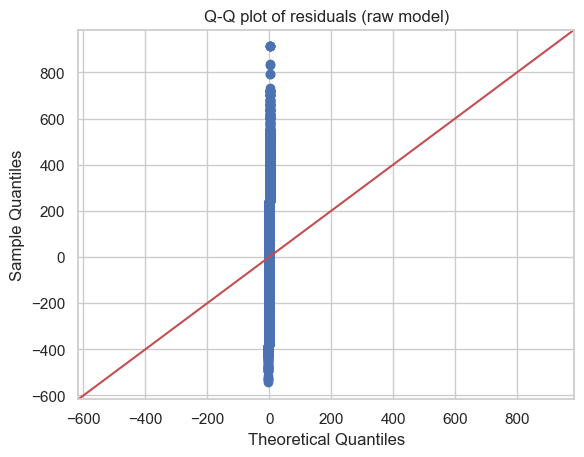

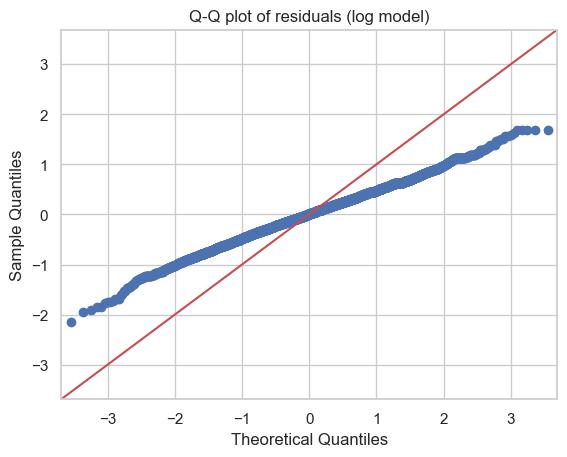

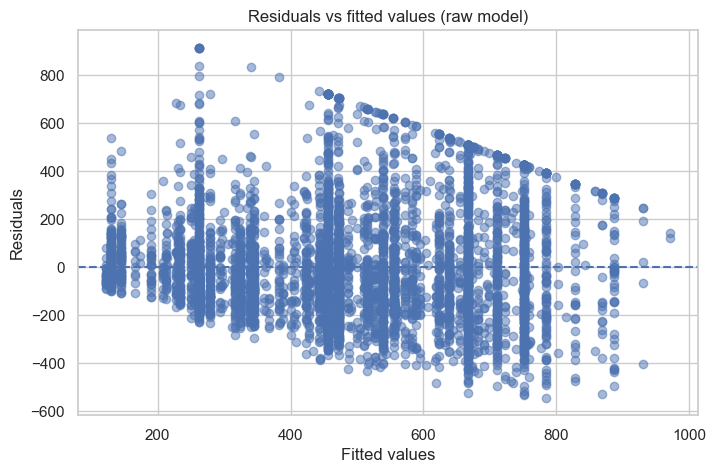

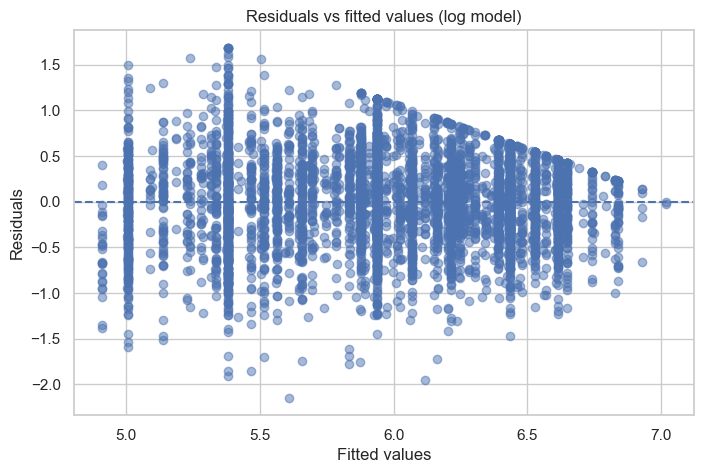

In [ ]:
# 11. Diagnostic tests

def run_diagnostics(model, label):
    print(f"\n--- Diagnostics ({label}) ---")
    jb_stat, jb_p, skew, kurtosis = jarque_bera(model.resid)
    print("\nJarque-Bera test for residual normality:")
    print(f"JB statistic = {jb_stat:.3f}, p-value = {jb_p:.5f}")
    print(f"Skewness = {skew:.3f}, Kurtosis = {kurtosis:.3f}")

    bp_test = het_breuschpagan(model.resid, model.model.exog)
    bp_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]

    print("\nBreusch-Pagan test for heteroscedasticity:")
    for label_name, value in zip(bp_labels, bp_test):
        print(f"{label_name}: {value:.5f}")
run_diagnostics(model_raw, "RAW")
run_diagnostics(model_log, "LOG")


# Q-Q (quantile-quantile) plot of residuals used here as a complementary analysis.
#RAW
sm.qqplot(model_raw.resid, line='45')
plt.title("Q-Q plot of residuals (raw model)")
plt.show()
#LOG
sm.qqplot(model_log.resid, line='45')
plt.title("Q-Q plot of residuals (log model)")
plt.show()
# Quantile–Quantile (Q–Q) plots were used as a graphical diagnostic tool to assess whether the residuals from the regression models follow a normal distribution. This is an important assumption in ordinary least squares (OLS) regression, particularly for valid statistical inference.
# The Q–Q plots provide a visual complement to formal statistical tests, such as the Jarque–Bera test. While the statistical tests indicate deviations from normality in both models, the graphical analysis reveals that the log specification offers a clear improvement.
# This is particularly important because OLS inference relies on approximately normally distributed residuals, especially in finite samples. A better approximation to normality increases the reliability of hypothesis testing and confidence intervals.



# Residuals vs fitted values as a diagnostic test used here as a complementary analysis.
#RAW
plt.figure(figsize=(8, 5))
plt.scatter(model_raw.fittedvalues, model_raw.resid, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values (raw model)")
plt.show()
#LOG
plt.figure(figsize=(8, 5))
plt.scatter(model_log.fittedvalues, model_log.resid, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values (log model)")
plt.show()
# A residuals versus fitted values plot was used as a diagnostic tool to assess key assumptions of the ordinary least squares (OLS) model, particularly linearity and homoscedasticity.
# This diagnostic complements formal tests such as the Breusch–Pagan test by providing a visual assessment of heteroscedasticity.


11. Diagnostic tests -
These diagnostic tests complement the regression and ANOVA analysis by validating the underlying assumptions of the model. While the regression results provide estimates of relationships, the diagnostics ensure that these estimates can be interpreted reliably.
The Jarque–Bera test was used to assess residual normality, while the Breusch–Pagan test was used to test for heteroscedasticity.The results indicated that the log transformation substantially improved residual normality and reduced, though did not eliminate, heteroscedasticity. This justified the combined use of the log specification and HC3 robust standard errors.
- Overall, the Q–Q plots confirm that the log-transformed model provides a better statistical fit, with residuals that more closely satisfy the normality assumption. While the raw model is useful for descriptive purposes, the log specification is preferred for econometric analysis due to its improved distributional properties and more reliable inference.
- Overall, the residual diagnostics confirm that the log-transformed model provides a better fit to the data, with more stable variance and fewer distortions caused by extreme values. While the raw model is informative for descriptive purposes, the log specification is preferred for inference and modelling due to its improved statistical properties.

12. Coefficient interpretation -
To facilitate interpretation of the regression results, coefficient tables were constructed for both the raw and log-transformed models. While the raw model coefficients are expressed in monetary units (£), the log specification allows coefficients to be interpreted in percentage terms, providing a more intuitive understanding of relative effects.
For the log model, coefficients were transformed using the exponential function to obtain approximate percentage differences in household expenditure.

In [ ]:
# 12. Coefficient interpretation

coef_table_raw = pd.DataFrame({
    "coefficient": model_raw.params
})
print("\nCoefficient interpretation table (RAW):")
print(coef_table_raw)


coef_table_log = pd.DataFrame({
    "coefficient": model_log.params,
    "pct_difference": (np.exp(model_log.params) - 1) * 100
})
# The intercept is not substantively interpreted as a percentage change.
print("\nCoefficient interpretation table (LOG):")
print(coef_table_log)


Coefficient interpretation table (RAW):
                                                    coefficient
Intercept                                            340.541247
C(occupational_class)[T.Intermediate occupations]   -128.364613
C(occupational_class)[T.Routine and manual occu...  -194.900655
C(occupational_class)[T.Never worked and long t...  -217.521003
C(occupational_class)[T.Not classified for othe...  -210.855448
C(tenure_type)[T.Private rented]                     103.964485
C(tenure_type)[T.Owned]                              132.510830
C(number_of_adults)[T.2 adults]                      193.754936
C(number_of_adults)[T.3 adults]                      310.752013
C(number_of_adults)[T.4 and more adults]             413.582318
C(number_of_children)[T.One child]                    43.729361
C(number_of_children)[T.Two or more children]         84.498521

Coefficient interpretation table (LOG):
                                                    coefficient  \
Intercept          

12. Coefficient interpretation -
This coefficient interpretation complements the regression and ANOVA results by providing a more intuitive understanding of the magnitude and direction of effects. While statistical tests establish significance, the coefficient tables translate these effects into economically meaningful terms, allowing for clearer interpretation of household behaviour.
The coefficient analysis confirms that household composition, particularly the number of adults, is the primary driver of expenditure, followed by socio-economic status and housing tenure. While both model specifications yield consistent conclusions, the log-transformed model provides a more interpretable and statistically reliable framework. Consequently, it is preferred for analytical purposes, while the raw model is retained for descriptive context.

In [ ]:
# Grouped means (descriptive only) used here as a complementary analysis
#group_means_raw = df.groupby(
#    ["occupational_class", "tenure_type", "number_of_adults", "number_of_children"],
#    observed=True
#)["expenditure"].mean()
#print("\nGrouped means (RAW - £):")
#print(group_means_raw.head(10))
#
#group_means_log = df.groupby(
#    ["occupational_class", "tenure_type", "number_of_adults", "number_of_children"],
#    observed=True
#)["log_expenditure"].mean()
#print("\nGrouped means (LOG):")
#print(group_means_log.head(10))


#The grouped means analysis confirms the main findings of the regression models, namely that household composition, socio-economic status, and tenure type are key determinants of expenditure.
# While the raw values illustrate absolute differences, the log-transformed results provide a clearer and more stable comparison across groups.
# This reinforces the robustness of the empirical findings.

# Conclusion

- Research question:
Is there a relationship between occupational class, tenure type, number of adults, number of children, and household expenditure?

- Answer:
Yes. The empirical results provide strong evidence of a statistically significant relationship between household expenditure and the explanatory variables.
The regression models indicate that occupational class, tenure type, number of adults, and number of children are all significant predictors of expenditure. The overall model is highly statistically significant (p < 0.001), confirming that the explanatory variables jointly influence household spending behaviour.
Among the predictors, household composition—particularly the number of adults—has the strongest effect on expenditure. Socio-economic status, captured by occupational class, is also an important determinant, with lower occupational groups associated with lower levels of spending. Housing tenure further contributes to variation in expenditure, reflecting differences in economic resources and housing-related costs. The number of children has a positive but comparatively smaller effect.
The log-transformed specification provides a better fit and more interpretable results, reinforcing the robustness of these findings.


Null hypothesis (H0):
- There is no relationship between household expenditure and the explanatory variables.
- In other words, all slope coefficients are equal to zero.
- H0: β₁ = β₂ = β₃ = β₄ = 0
- H0: all slope coefficients = 0
Alternative hypothesis (H1):
- There is a relationship between household expenditure and at least one of the explanatory variables.
- In other words, at least one slope coefficient is different from zero.
- H1: At least one β ≠ 0
- H1: at least one slope coefficient ≠ 0

The raw regression model was statistically significant (F = 327.5, p < 0.001), indicating that the explanatory variables jointly predict household expenditure. The raw model explained approximately 41.2% of the variation in household expenditure (R² = 0.412), which indicates a moderate fit.

The log-transformed regression model was also statistically significant (F = 440.4, p < 0.001), indicating that the explanatory variables jointly predict log household expenditure. The log model explained approximately 48.6% of the variation in log household expenditure (R² = 0.486), indicating a better fit than the raw specification.

Overall model significance

“The overall regression results indicate that household expenditure is significantly associated with occupational class, tenure type, number of adults, and number of children. The raw model is statistically significant (F = 327.5, p < 0.001) and explains 41.2% of the variation in expenditure. The log-transformed model provides a better fit (F = 440.4, p < 0.001; R² = 0.486), suggesting that the logarithmic specification is more appropriate for analysis.”

Occupational class

“Compared with households in higher managerial, administrative and professional occupations, all other occupational groups exhibit lower expenditure. In the raw model, these differences range from approximately £128 to £218. In the log model, this corresponds to reductions of around 20% to 45%, confirming a clear socio-economic gradient in household spending.”

Tenure type

“Housing tenure is also strongly associated with expenditure. Relative to households in public rented accommodation, those in private rented housing spend around £104 more in the raw model, while owner-occupied households spend around £133 more. In the log model, these effects correspond to approximately 39% and 46% higher expenditure, respectively.”

Number of adults

“Household composition, particularly the number of adults, is the strongest determinant of expenditure. Compared with single-adult households, households with two adults spend approximately £194 more, those with three adults spend around £311 more, and those with four or more adults spend around £414 more. In the log model, these differences translate into substantial percentage increases, reaching over 160% for households with four or more adults.”

Number of children

“The presence of children is associated with higher expenditure, although the effect is smaller than that of the number of adults. Households with one child spend around £44 more than those with no children, while households with two or more children spend around £84 more. In the log model, these effects correspond to approximately 10% and 20% higher expenditure.”

Assumptions of Linear Regression

The validity of the linear regression model relies on a set of classical assumptions, which were systematically evaluated using a range of diagnostic tests and complementary analyses.
- Linearity was assumed based on the model specification and supported by empirical evidence. In particular, the log-transformed specification provided a better fit, suggesting a more appropriate functional form for modelling household expenditure.
- The independence of observations was considered plausible, as the dataset consists of individual households, with no indication of clustering or repeated measurements.
- The normality of residuals was assessed using the Jarque–Bera test and Q–Q plots. The results indicated substantial deviations from normality in the raw model, characterised by skewness and excess kurtosis. However, the log transformation significantly improved the distribution of residuals, reducing skewness and bringing the residuals closer to a normal distribution. Given the large sample size, remaining deviations from normality are unlikely to materially affect inference.
- Homoscedasticity was evaluated using the Breusch–Pagan test and residuals versus fitted values plots. Both approaches indicated the presence of heteroscedasticity, particularly in the raw model. Although the log transformation reduced this issue, it did not eliminate it entirely. To address this, heteroskedasticity-robust standard errors (HC3) were employed, ensuring that statistical inference remains valid even in the presence of non-constant variance.
- Multicollinearity was examined using Variance Inflation Factors (VIF). All VIF values were well below conventional thresholds, indicating no evidence of problematic multicollinearity. This confirms that the explanatory variables represent distinct aspects of household socio-economic characteristics.
- In addition to these diagnostics, ANOVA was used to decompose the variance and assess the relative importance of each explanatory variable, while Chi-square tests were conducted as a complementary analysis to explore associations between categorical predictors. These tests do not directly address the main research question but provide useful insight into the structure of the data.
- Overall, while some classical assumptions—particularly normality and homoscedasticity—are not fully satisfied, the combination of a log transformation, large sample size, and robust standard errors (HC3) ensures that the regression results are reliable and the conclusions are robust.
- Taken together, the diagnostic results support the use of the log-transformed model with robust standard errors as the preferred specification for inference.